In [ ]:
# imblearn 라이브러리 설치
!pip install imblearn --quiet

# 클래스 불균형 처리

## 1. 오버샘플링

오버샘플링은 소수 클래스의 샘플 수를 늘려 클래스 불균형을 해소하는 기법입니다. 이는 모델이 소수 클래스를 더 잘 학습할 수 있도록 돕습니다.
**'오버샘플링을 테스트 데이터가 아닌 학습 데이터(Train Set)에만 적용해야 함**  
**"검증(Test) 데이터X"**

원본 데이터 분포: Counter({np.int64(0): 451, np.int64(1): 49})


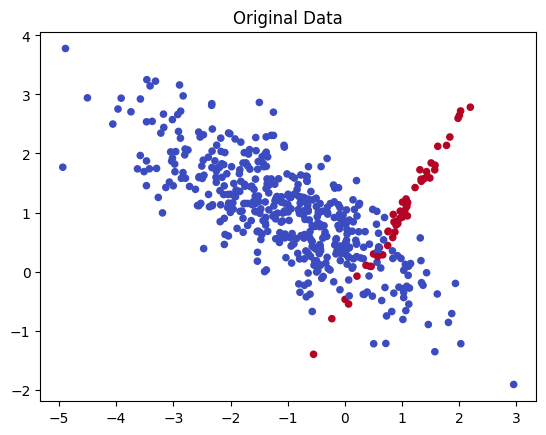

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import make_classification

# 9:1 불균형 데이터 생성
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, weights=[0.9], flip_y=0, random_state=42)

#X,y는 np.array로 X:(500,2). y:(500,). X:데이터정보, y:클래스. 인덱스 동기화

print("원본 데이터 분포:", Counter(y))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20)
plt.title("Original Data")
plt.show()

### 1.1. Random Oversampling

가장 단순한 방식으로, 수가 적은 클래스의 데이터를 그대로 복사해서 개수를 늘리는 기법입니다. 데이터 손실이 전혀 없다는 장점이 있지만, 분포의 변화가 없어,  **과적합(Overfitting)** 문제가 생기기 쉽습니다.

Before: Counter({np.int64(0): 451, np.int64(1): 49}) / After: Counter({np.int64(0): 451, np.int64(1): 451})


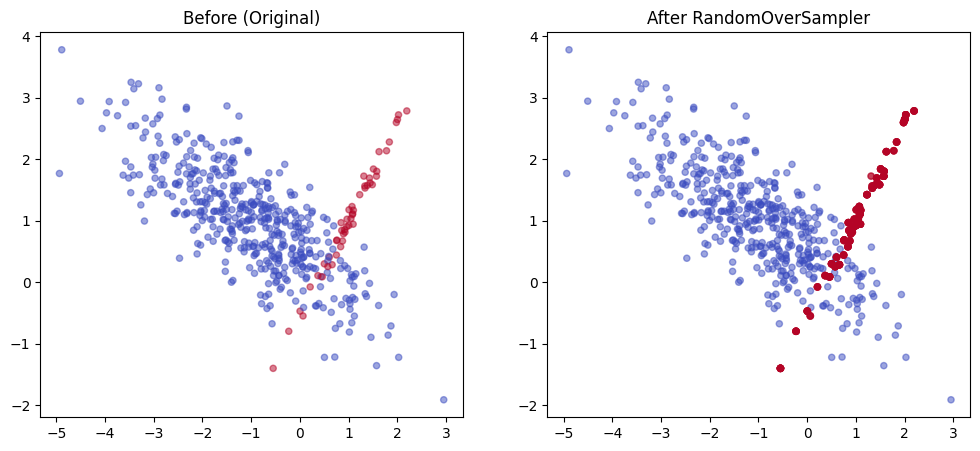

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

print("Before:", Counter(y), "/ After:", Counter(y_res))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.5)
ax[0].set_title("Before (Original)")
ax[1].scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='coolwarm', s=20, alpha=0.5)
ax[1].set_title("After RandomOverSampler")
plt.show()

### 1.2. SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE는 임의의 소수 클래스 데이터로부터 인근 소수 클래스 사이에 새로운 데이터를 생성하는 방법이다. 임의의 소수 클래스에 해당하는 x를 잡고 그로부터 가장 가까운 k개의 이웃을 찾은 다음, k개의 이웃과 x 사이에 임의의 새로운 데이터를 생성한다. Random Oversampling의 과적합 문제를 완화하고, 더 다양한 샘플을 생성합니다.

Before: Counter({np.int64(0): 451, np.int64(1): 49}) / After: Counter({np.int64(0): 451, np.int64(1): 451})


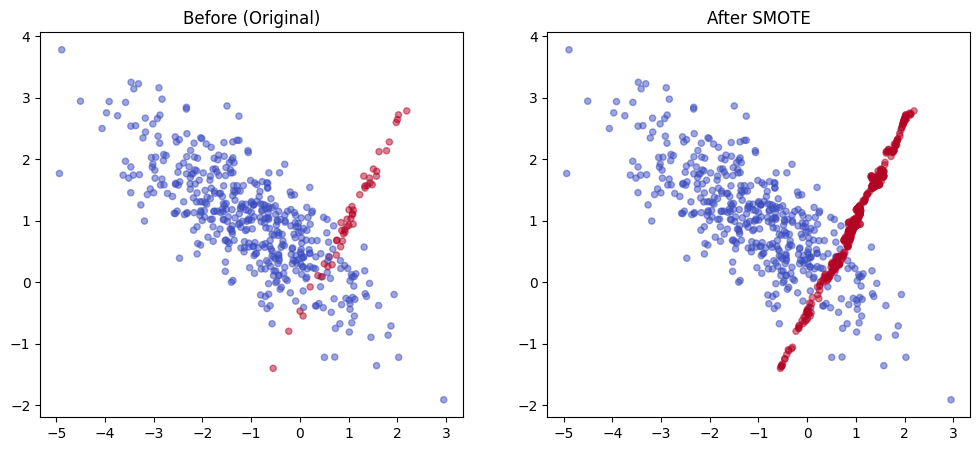

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("Before:", Counter(y), "/ After:", Counter(y_res))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.5)
ax[0].set_title("Before (Original)")
ax[1].scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='coolwarm', s=20, alpha=0.5)
ax[1].set_title("After SMOTE")
plt.show()

### 1.3. Borderline SMOTE

Borderline SMOTE는 소수 클래스 중 경계선에 위치한 샘플들을 중심으로 Smote를 적용한다. 이는 노이즈에 덜 민감하고, 모델의 결정 경계를 개선하는 데 효과적입니다.

Before: Counter({np.int64(0): 451, np.int64(1): 49}) / After: Counter({np.int64(0): 451, np.int64(1): 451})


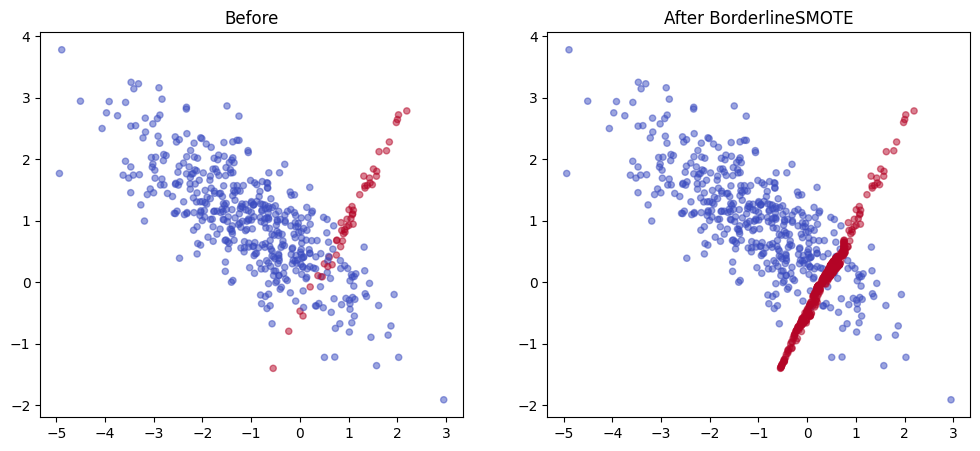

In [ ]:
from imblearn.over_sampling import BorderlineSMOTE

bsmote = BorderlineSMOTE(random_state=42)
X_res, y_res = bsmote.fit_resample(X, y)

print("Before:", Counter(y), "/ After:", Counter(y_res))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.5)
ax[0].set_title("Before")
ax[1].scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='coolwarm', s=20, alpha=0.5)
ax[1].set_title("After BorderlineSMOTE")
plt.show()

### 1.4. K-Means SMOTE

K-Means SMOTE는 K-means 클러스터링 알고리즘을 사용하여 전체 데이터를 클러스터링하고, 소수 클래스 샘플이 적게 포함된 군집에 소수에 샘플을 추가하는 방법이다. 소수 클래스를 여러 군집으로 나눈 후, 각 군집 내에서 SMOTE를 적용하여 샘플을 생성한다. 즉, 전체 데이터를 군집으로 나누고(K-Means), 그중 소수 데이터가 잘 모여 있는 구역을 타겟팅하여 데이터를 증식(SMOTE)시키는 기법이다. 이는 데이터의 군집 구조를 반영하여 보다 현실적인 샘플을 생성할 수 있습니다.

Before: Counter({np.int64(0): 451, np.int64(1): 49}) / After: Counter({np.int64(0): 451, np.int64(1): 451})


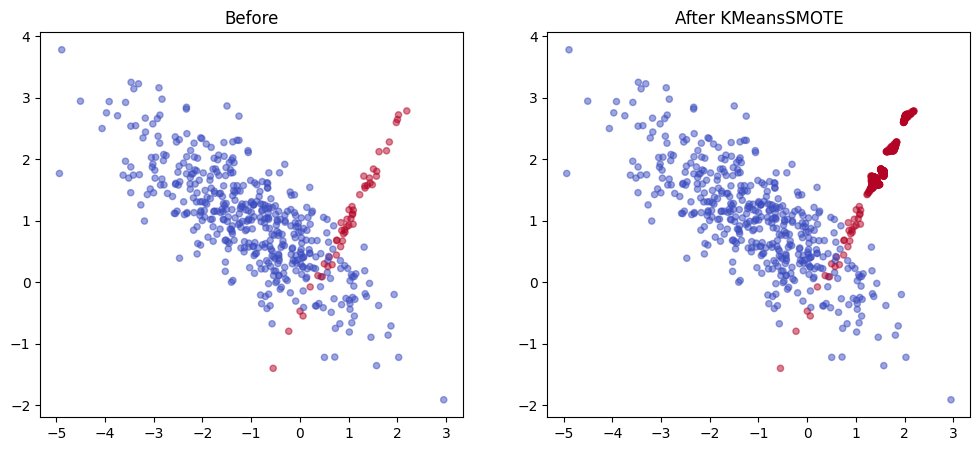

In [ ]:
from imblearn.over_sampling import KMeansSMOTE

# cluster_std는 데이터 분포에 따라 조정이 필요할 수 있습니다.
kms = KMeansSMOTE(random_state=42)
X_res, y_res = kms.fit_resample(X, y)

print("Before:", Counter(y), "/ After:", Counter(y_res))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.5)
ax[0].set_title("Before")
ax[1].scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='coolwarm', s=20, alpha=0.5)
ax[1].set_title("After KMeansSMOTE")
plt.show()

### 1.5. SVM SMOTE

SVM SMOTE는 SVM (Support Vector Machine)의 결정 경계 주변에 위치한 소수 클래스 샘플들을 중심으로, support vector를 경계 데이터로 삼아 Smote를 적용하는 방법이다. 이는 경계선 부근의 샘플을 강조하여 모델의 분류 성능을 향상시킵니다.

Before: Counter({np.int64(0): 451, np.int64(1): 49}) / After: Counter({np.int64(0): 451, np.int64(1): 451})


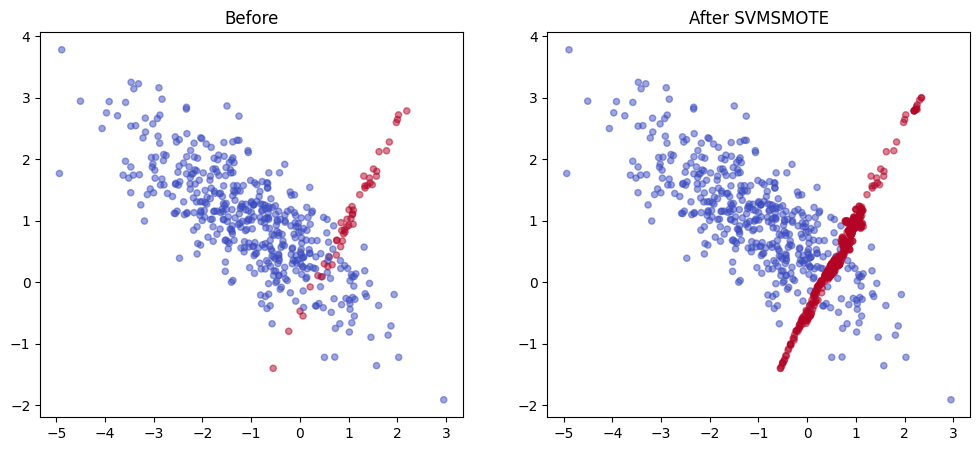

In [ ]:
from imblearn.over_sampling import SVMSMOTE

svms = SVMSMOTE(random_state=42)
X_res, y_res = svms.fit_resample(X, y)

print("Before:", Counter(y), "/ After:", Counter(y_res))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.5)
ax[0].set_title("Before")
ax[1].scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='coolwarm', s=20, alpha=0.5)
ax[1].set_title("After SVMSMOTE")
plt.show()

### 1.6. ADASYN

ADASYN (Adaptive Synthetic Sampling)은 가중치를 통해 SMOTE를 적용시키는 방법이다. 분류하기 어려운(다수 클래스에 파묻힌) 소수 데이터를 찾아, 그 주변을 집중적으로 보강하는 적응형 오버샘플링 기법. 분류 경계선의 학습능력을 강화시킨다.

Before: Counter({np.int64(0): 451, np.int64(1): 49}) / After: Counter({np.int64(0): 451, np.int64(1): 450})


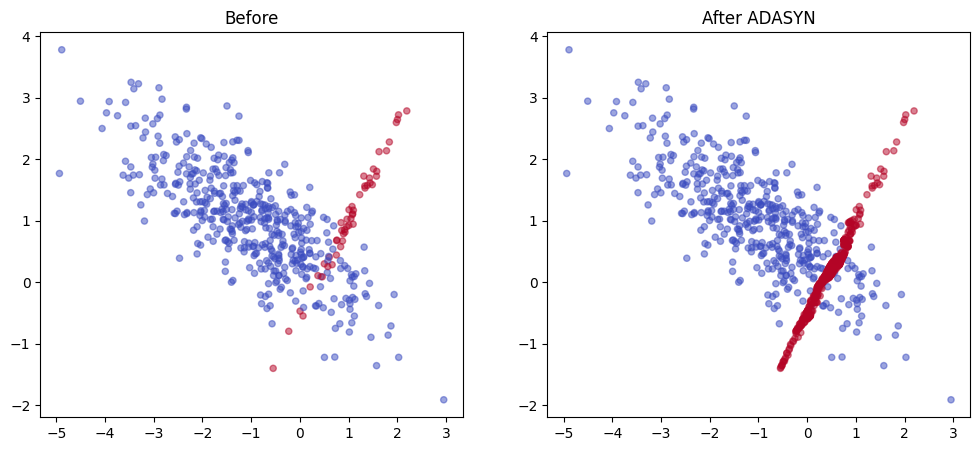

In [ ]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_res, y_res = adasyn.fit_resample(X, y)

print("Before:", Counter(y), "/ After:", Counter(y_res))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.5)
ax[0].set_title("Before")
ax[1].scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='coolwarm', s=20, alpha=0.5)
ax[1].set_title("After ADASYN")
plt.show()

##2. 언더샘플링

언더샘플링은 다수 클래스의 샘플 수를 줄여 클래스 불균형을 해소하는 기법입니다. 이는 계산 비용을 줄일 수 있지만, 정보 손실의 위험이 있습니다.

### 2.1. Random Undersampling

Random Undersampling은 다수 클래스의 샘플들을 무작위로 제거하여 수를 줄이는 가장 간단한 언더샘플링 기법입니다. 구현이 간단하지만, 중요한 정보를 포함하는 샘플이 제거될 위험이 있습니다.

Before: Counter({np.int64(0): 451, np.int64(1): 49}) / After: Counter({np.int64(0): 49, np.int64(1): 49})


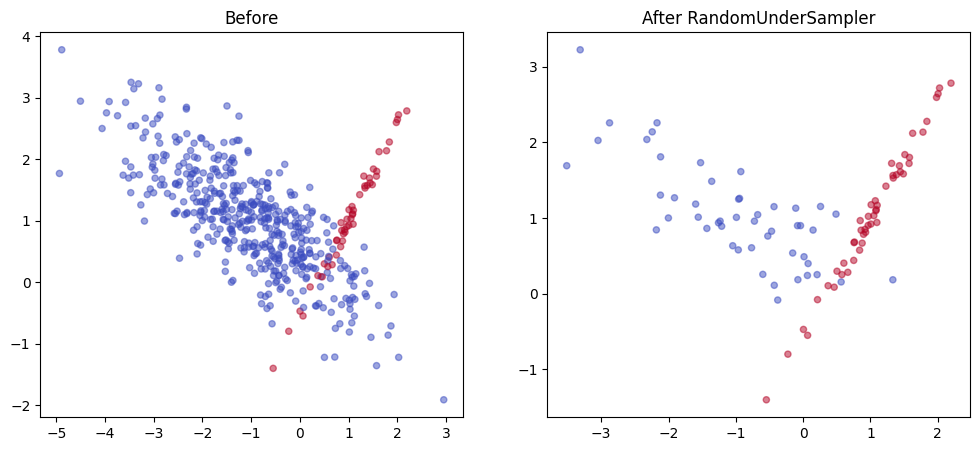

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

print("Before:", Counter(y), "/ After:", Counter(y_res))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.5)
ax[0].set_title("Before")
ax[1].scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='coolwarm', s=20, alpha=0.5)
ax[1].set_title("After RandomUnderSampler")
plt.show()

### 2.2. Cluster Centroids

Cluster Centroids는 다수 클래스 샘플들을 군집화하고, 각 군집의 중심을 대표 샘플로 사용하여 다수 클래스의 수를 줄이는 기법입니다. 이는 다수 클래스의 분포를 더 잘 유지하면서 샘플 수를 줄일 수 있습니다.

Before: Counter({np.int64(0): 451, np.int64(1): 49}) / After: Counter({np.int64(0): 49, np.int64(1): 49})


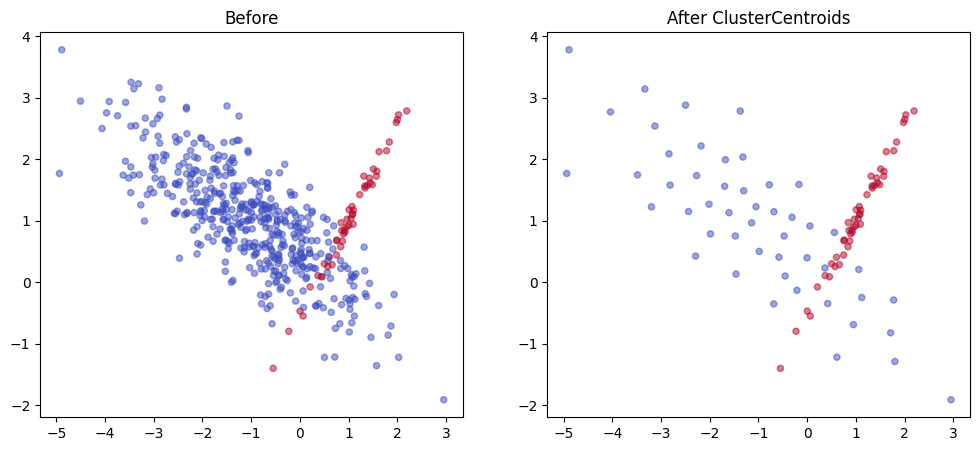

In [ ]:
from imblearn.under_sampling import ClusterCentroids

cc = ClusterCentroids(random_state=42)
X_res, y_res = cc.fit_resample(X, y)

print("Before:", Counter(y), "/ After:", Counter(y_res))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.5)
ax[0].set_title("Before")
ax[1].scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='coolwarm', s=20, alpha=0.5)
ax[1].set_title("After ClusterCentroids")
plt.show()

### 2.3. Condensed Nearest Neighbour

Condensed Nearest Neighbour (CNN)은 다수 클래스 샘플 중 분류 경계에 영향을 미치지 않는 샘플들을 제거하여 다수 클래스의 수를 줄이는 기법입니다. 이는 중요한 정보를 유지하면서 불필요한 샘플을 제거합니다.

Before: Counter({np.int64(0): 451, np.int64(1): 49}) / After: Counter({np.int64(1): 49, np.int64(0): 25})


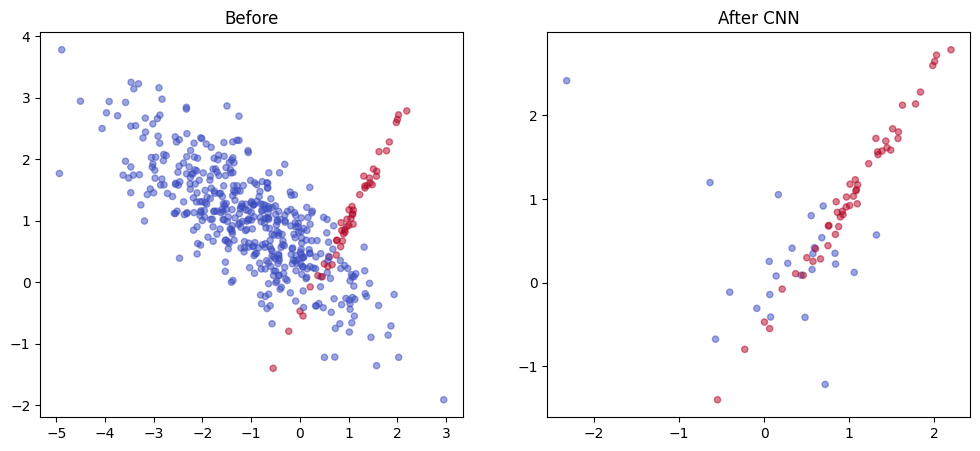

In [ ]:
from imblearn.under_sampling import CondensedNearestNeighbour

cnn = CondensedNearestNeighbour(random_state=42)
X_res, y_res = cnn.fit_resample(X, y)

print("Before:", Counter(y), "/ After:", Counter(y_res))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.5)
ax[0].set_title("Before")
ax[1].scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='coolwarm', s=20, alpha=0.5)
ax[1].set_title("After CNN")
plt.show()

### 2.4. Edited Nearest Neighbours

Edited Nearest Neighbours (ENN)은 다수 클래스 샘플 중 주변 이웃과 다른 클래스로 분류되는 샘플들을 제거하여 노이즈를 줄이는 기법입니다. 이는 모델의 일반화 성능을 향상시킬 수 있습니다.

Before: Counter({np.int64(0): 451, np.int64(1): 49}) / After ENN: Counter({np.int64(0): 433, np.int64(1): 49})


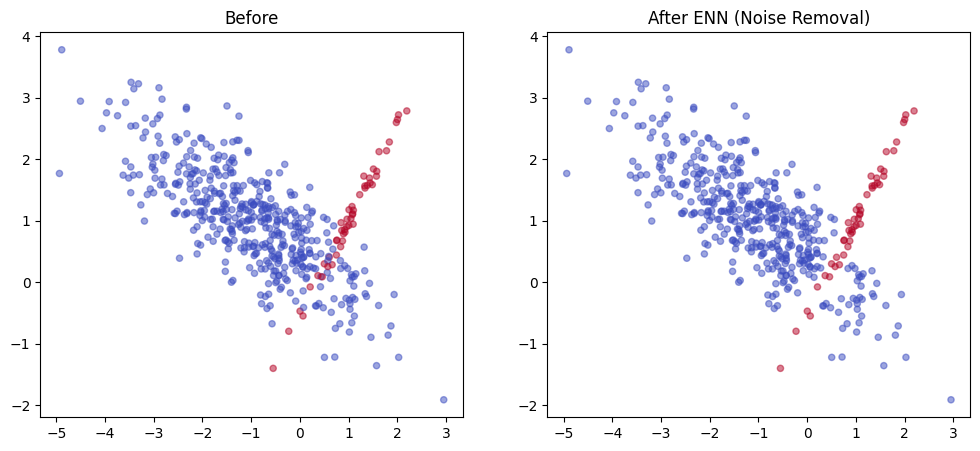

In [ ]:
from imblearn.under_sampling import EditedNearestNeighbours
import matplotlib.pyplot as plt
from collections import Counter

# ENN 적용
enn = EditedNearestNeighbours()
X_res, y_res = enn.fit_resample(X, y)

print("Before:", Counter(y), "/ After ENN:", Counter(y_res))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.5)
ax[0].set_title("Before")
ax[1].scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='coolwarm', s=20, alpha=0.5)
ax[1].set_title("After ENN (Noise Removal)")
plt.show()

### 2.5. AllKNN

AllKNN은 ENN을 반복적으로 적용하여 노이즈를 제거하고 다수 클래스의 수를 줄이는 기법입니다. 이는 보다 강력한 노이즈 제거 효과를 제공합니다.

Before: Counter({np.int64(0): 451, np.int64(1): 49}) / After AllKNN: Counter({np.int64(0): 429, np.int64(1): 49})


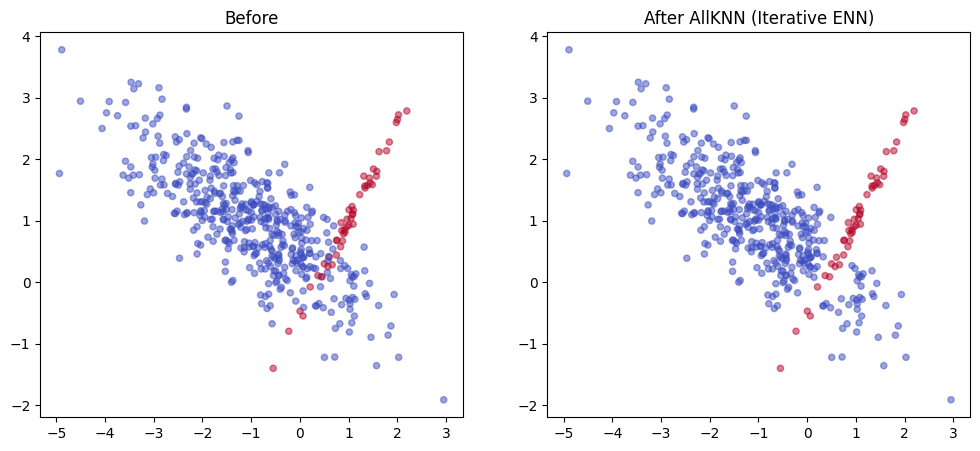

In [ ]:
from imblearn.under_sampling import AllKNN

# AllKNN 적용
allknn = AllKNN()
X_res, y_res = allknn.fit_resample(X, y)

print("Before:", Counter(y), "/ After AllKNN:", Counter(y_res))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.5)
ax[0].set_title("Before")
ax[1].scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='coolwarm', s=20, alpha=0.5)
ax[1].set_title("After AllKNN (Iterative ENN)")
plt.show()

## 3. 복합샘플링

복합샘플링은 오버샘플링과 언더샘플링을 결합하여 클래스 불균형을 처리하는 기법입니다. 두 가지 방법의 장점을 결합하여 더 나은 성능을 기대할 수 있습니다.

### 3.1. SMOTETomek

SMOTETomek은 SMOTE로 소수 클래스를 오버샘플링한 후, Tomek Links를 사용하여 다수 클래스 샘플과 소수 클래스 샘플 간의 중복되거나 노이즈가 있는 샘플을 제거하는 복합 샘플링 기법입니다. 이는 클래스 간의 경계를 더 명확하게 합니다.

Before: Counter({np.int64(0): 451, np.int64(1): 49}) / After: Counter({np.int64(0): 449, np.int64(1): 449})


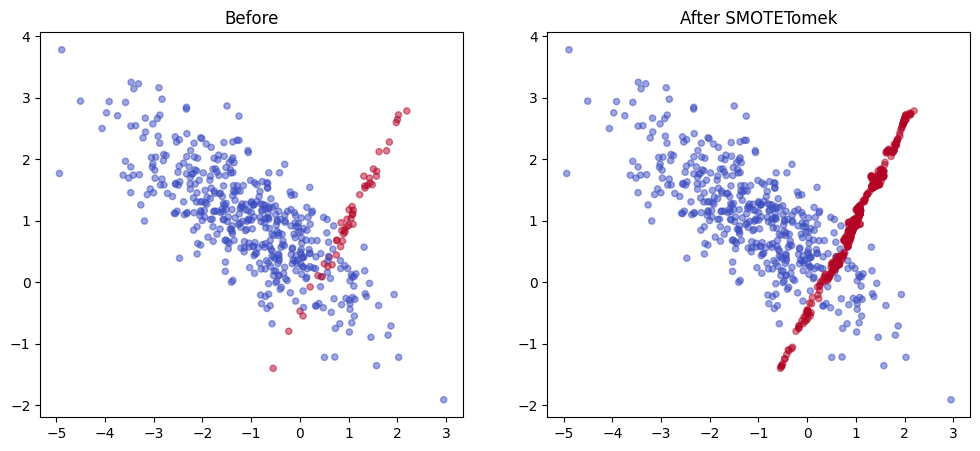

In [ ]:
from imblearn.combine import SMOTETomek

st = SMOTETomek(random_state=42)
X_res, y_res = st.fit_resample(X, y)

print("Before:", Counter(y), "/ After:", Counter(y_res))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.5)
ax[0].set_title("Before")
ax[1].scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='coolwarm', s=20, alpha=0.5)
ax[1].set_title("After SMOTETomek")
plt.show()

### 3.2. SMOTEENN

SMOTEENN은 SMOTE로 소수 클래스를 오버샘플링한 후, ENN (Edited Nearest Neighbours)을 적용하여 다수 클래스 샘플 중 노이즈가 있는 샘플을 제거하는 복합 샘플링 기법입니다. 이는 SMOTETomek과 유사하게 클래스 간의 경계를 개선합니다.

Before: Counter({np.int64(0): 451, np.int64(1): 49}) / After: Counter({np.int64(1): 437, np.int64(0): 432})


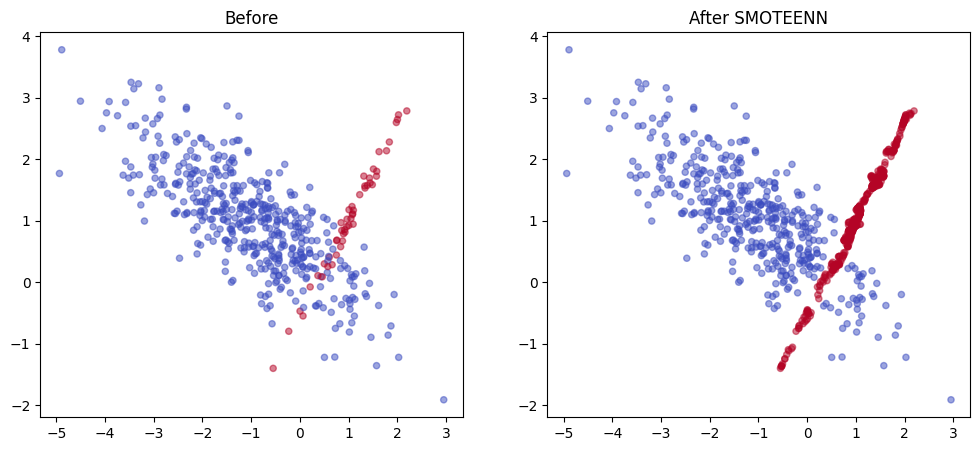

In [ ]:
from imblearn.combine import SMOTEENN

sme = SMOTEENN(random_state=42)
X_res, y_res = sme.fit_resample(X, y)

print("Before:", Counter(y), "/ After:", Counter(y_res))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.5)
ax[0].set_title("Before")
ax[1].scatter(X_res[:, 0], X_res[:, 1], c=y_res, cmap='coolwarm', s=20, alpha=0.5)
ax[1].set_title("After SMOTEENN")
plt.show()